<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXVodWNsM3Bia3duZGljZzRqMTI2MGFiZjlkZzBwcmhuaWxydjlpaiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AOSwwqVjNZlDO/giphy.gif" alt="Beam Oscillation" width="400" style="border-radius:10px;">

  <h3 style="color:#ffffff; margin-top:15px;"><b>Solution Example of Truss Element</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Matrix Analisys</p>
  <p><b>Year:</b> MAYO - 2026</p>

</div>

#### Libraries

In [1]:
import numpy as np                                                                                                      # Numerical operations and arrays
import pandas as pd                                                                                                     # DataFrame tables for visualization
import matplotlib.pyplot as plt                                                                                         # Plotting tools

from repo_maxtrix_analisys import *                                                                                     # Import package classes and functions

#### Case
![alt text](image-12.png)

#### Data

In [2]:
E = 21000000                                                                                                        # Modulus of elasticity
l = 3                                                                                                               # Base length of the truss panels
L = [l,l,np.sqrt(l**2 + l**2),np.sqrt(l**2 + l**2),l,l]                                                             # Length of each truss element
thethas = [0,90,135,45,90,0]                                                                                        # Orientation angle of each element in degrees
db = 0.018                                                                                                          # Bar diameter
A = np.pi * db**(2) / 4                                                                                             # Cross-sectional area of the bars
local_dof = 2                                                                                                       # Local DOF per element
Global_dof = 4                                                                                                      # Local DOF per element
nglt = 8                                                                                                            # Number of global DOF inluding supports
gdl = 5                                                                                                             # Number of global DOF          

Lee = np.array([                                                                                                    # Placement vectors of each element
    [1, 2, 3, 4],                                                                                                   # Element 1
    [6, 7, 1, 2],                                                                                                   # Element 2
    [5, 8, 1, 2],                                                                                                   # Element 3
    [6, 7, 3, 4],                                                                                                   # Element 4
    [5, 8, 3, 4],                                                                                                   # Element 5
    [6, 7, 5, 8],                                                                                                   # Element 6
])

element_names = [f'Elem_{i+1}' for i in range(len(Lee))]                                                            # Element labels for the table
Lee_table = pd.DataFrame(                                                                                           # Convert placement vectors to DataFrame
    Lee,                                                                                                            # Placement vector array
    index=element_names,                                                                                            # DataFrame row names
    columns=["GDLg_Ax", "GDLg_Ay", "GDLg_Bx", "GDLg_By"]                                                            # Global DOF column names
)
print("=" * 120)                                                                                                    # Print table separator
print('Placement Vectors')                                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
Lee_table                                                                                                           # Display placement vectors table

Placement Vectors


,GDLg_Ax,GDLg_Ay,GDLg_Bx,GDLg_By
Elem_1,1,2,3,4
Elem_2,6,7,1,2
Elem_3,5,8,1,2
Elem_4,6,7,3,4
Elem_5,5,8,3,4
Elem_6,6,7,5,8


#### Solution

##### Stiffness Matrix in Local Coordinates

In [3]:
# --- Create structure container -----------------------------------------------------------------------------------
structure = Manager_K_T_elements2D(method= 'ARM')                                                                   # Create an instance of the MF structure

# --- Add ARM elements to the structure -----------------------------------------------------------------------------
for i in np.arange(0, len(thethas), 1):                                                                             # Loop to add each element
    structure.add_element(ARM_K_T_Element2D(E = E,A = A, L = L[i], thetha= thethas[i]))                             # Add ARM element with its properties   

In [4]:
# --- Stack local stiffness matrices --------------------------------------------------------------------------------
K_all = structure.stacked_stiffness_matrices()                                                                      # Stacked stiffness matrix (2N x 2)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_elem = len(structure.elements)                                                                                    # Number of elements in the structure
n_dof  = local_dof                                                                                                  # Number of local DOF per element

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for local stiffness matrices
    [(f'Elem_{e+1}', f'DOF_L_{d+1}') for e in range(n_elem) for d in range(n_dof)],                                 # Element and local DOF labels
    names=['Element', 'Local DOF']                                                                                  # Index level names
)

K_all_df = pd.DataFrame(K_all, index=rows, columns=[f'DOF_L_{i}' for i in np.arange(1, K_all.shape[1] + 1)])        # Convert to DataFrame for better visualization
print("=" * 120)                                                                                                    # Print table separator
print('Local Stiffness Matrices')                                                                                   # Print table title
print("=" * 120)                                                                                                    # Print table separator
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices 

Local Stiffness Matrices


DOF_L_1      DOF_L_2
Element Local DOF                          
Elem_1  DOF_L_1    1781.283035 -1781.283035
        DOF_L_2   -1781.283035  1781.283035
Elem_2  DOF_L_1    1781.283035 -1781.283035
        DOF_L_2   -1781.283035  1781.283035
Elem_3  DOF_L_1    1259.557313 -1259.557313
        DOF_L_2   -1259.557313  1259.557313
Elem_4  DOF_L_1    1259.557313 -1259.557313
        DOF_L_2   -1259.557313  1259.557313
Elem_5  DOF_L_1    1781.283035 -1781.283035
        DOF_L_2   -1781.283035  1781.283035
Elem_6  DOF_L_1    1781.283035 -1781.283035
        DOF_L_2   -1781.283035  1781.283035

##### Transformation Matrix

In [5]:
# --- Stack Transformation matrices --------------------------------------------------------------------------------
T_all = structure.stacked_transformation_matrices()                                                                 # Stacked transformation matrix (4N x 2)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_dof  = Global_dof                                                                                                 # Number of local-global DOF per element
rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for transformation matrices
    [(f'Elem_{e+1}', f'DOF_L_G_{d+1}') for e in range(n_elem) for d in range(n_dof)],                               # Element and local-global DOF labels
    names=['Element', 'Local - Global DOF']                                                                         # Index level names
)

T_all_df = pd.DataFrame(T_all, index=rows, columns=['Column 1', 'Column 2'])                                        # Convert to DataFrame for better visualization
print("=" * 120)                                                                                                    # Print table separator
print('Transformation Matrices')                                                                                    # Print table title
print("=" * 120)                                                                                                    # Print table separator
T_all_df.head(len(T_all_df))                                                                                        # Display stacked matrices


Transformation Matrices


Column 1      Column 2
Element Local - Global DOF                            
Elem_1  DOF_L_G_1           1.000000e+00  0.000000e+00
        DOF_L_G_2           0.000000e+00  0.000000e+00
        DOF_L_G_3           0.000000e+00  1.000000e+00
        DOF_L_G_4           0.000000e+00  0.000000e+00
Elem_2  DOF_L_G_1           6.123234e-17  0.000000e+00
        DOF_L_G_2           1.000000e+00  0.000000e+00
        DOF_L_G_3           0.000000e+00  6.123234e-17
        DOF_L_G_4           0.000000e+00  1.000000e+00
Elem_3  DOF_L_G_1          -7.071068e-01  0.000000e+00
        DOF_L_G_2           7.071068e-01  0.000000e+00
        DOF_L_G_3           0.000000e+00 -7.071068e-01
        DOF_L_G_4           0.000000e+00  7.071068e-01
Elem_4  DOF_L_G_1           7.071068e-01  0.000000e+00
        DOF_L_G_2           7.071068e-01  0.000000e+00
        DOF_L_G_3           0.000000e+00  7.071068e-01
        DOF_L_G_4           0.000000e+00  7.071068e-01
Elem_5  DOF_L_G_1           6.123234e-17  0.000000e+00
        DOF_L_G_2           1.000000e+00  0.000000e+00
        DOF_L_G_3           0.000000e+00  6.123234e-17
        DOF_L_G_4           0.000000e+00  1.000000e+00
Elem_6  DOF_L_G_1           1.000000e+00  0.000000e+00
        DOF_L_G_2           0.000000e+00  0.000000e+00
        DOF_L_G_3           0.000000e+00  1.000000e+00
        DOF_L_G_4           0.000000e+00  0.000000e+00

##### Stiffness Matrix in Global Coordinates

In [6]:
Keg_all = []                                                                                                        # Empty list to store global element stiffness matrices
for i in np.arange(0,n_elem,1):                                                                                     # Loop through each element
    Telem = structure.elements[i].transformation_ARM_matrix_2D()                                                    # Transformation matrix of element i
    Kelem = structure.elements[i].stiffness_matrix_ARM_AE()                                                         # Local stiffness matrix of element i
    Keg_all.append(Telem@Kelem@Telem.T)                                                                             # Transform local stiffness matrix to global coordinates

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

Keg_stack = np.vstack(Keg_all)                                                                                      # Stack all global element stiffness matrices
Keg_stack_df = pd.DataFrame(Keg_stack, index=rows,columns=[f'GLDg' for i in range(Global_dof)])                     # Convert stacked matrices to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Stiffness Matrices')                                                                                  # Print table title
print("=" * 120)                                                                                                    # Print table separator
Keg_stack_df.round(3)                                                                                               # Display rounded global element matrices

Global Stiffness Matrices


GLDg      GLDg      GLDg      GLDg
Element Placement Vector                                        
Elem_1  GDLg_1            1781.283     0.000 -1781.283     0.000
        GDLg_2               0.000     0.000     0.000     0.000
        GDLg_3           -1781.283     0.000  1781.283     0.000
        GDLg_4               0.000     0.000     0.000     0.000
Elem_2  GDLg_6               0.000     0.000    -0.000    -0.000
        GDLg_7               0.000  1781.283    -0.000 -1781.283
        GDLg_1              -0.000    -0.000     0.000     0.000
        GDLg_2              -0.000 -1781.283     0.000  1781.283
Elem_3  GDLg_5             629.779  -629.779  -629.779   629.779
        GDLg_8            -629.779   629.779   629.779  -629.779
        GDLg_1            -629.779   629.779   629.779  -629.779
        GDLg_2             629.779  -629.779  -629.779   629.779
Elem_4  GDLg_6             629.779   629.779  -629.779  -629.779
        GDLg_7             629.779   629.779  -629.779  -629.779
        GDLg_3            -629.779  -629.779   629.779   629.779
        GDLg_4            -629.779  -629.779   629.779   629.779
Elem_5  GDLg_5               0.000     0.000    -0.000    -0.000
        GDLg_8               0.000  1781.283    -0.000 -1781.283
        GDLg_3              -0.000    -0.000     0.000     0.000
        GDLg_4              -0.000 -1781.283     0.000  1781.283
Elem_6  GDLg_6            1781.283     0.000 -1781.283     0.000
        GDLg_7               0.000     0.000     0.000     0.000
        GDLg_5           -1781.283     0.000  1781.283     0.000
        GDLg_8               0.000     0.000     0.000     0.000

### Stiffness Matrix of the Structure.

#### Initialize Stiffness Matrix of the Structure

In [7]:
S = np.zeros((nglt, nglt))                                                                                          # Initialize global Structure stiffness matrix
rowsS = pd.Index(f'GDLg_{i+1}' for i in range(nglt))                                                                # Global DOF labels
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert global stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Initialize global Structure stiffness matrix')                                                               # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded global stiffness matrix

Initialize global Structure stiffness matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8
GDLg_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Assemble Stiffness Matrices of the Structure

In [8]:
for e in range(n_elem):                                                                                             # Loop through each element
    lee = Lee[e]                                                                                                    # Placement vector of element e
    Ke = Keg_all[e]                                                                                                 # Global stiffness matrix of element e
    S_assambler = Assembler(lee = lee, K = Ke, S = S, nglt= nglt)                                                   # Create assembler object for element e
    S = S_assambler.assambler_due_lee()                                                                             # Assemble element stiffness into the global matrix
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert assembled stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix')                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded assembled stiffness matrix

Global Structure Stiffness Matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8
GDLg_1,2411.062,-629.779,-1781.283,0.000,-629.779,-0.000,-0.000,629.779
GDLg_2,-629.779,2411.062,0.000,0.000,629.779,-0.000,-1781.283,-629.779
GDLg_3,-1781.283,0.000,2411.062,629.779,-0.000,-629.779,-629.779,-0.000
GDLg_4,0.000,0.000,629.779,2411.062,-0.000,-629.779,-629.779,-1781.283
GDLg_5,-629.779,629.779,-0.000,-0.000,2411.062,-1781.283,0.000,-629.779
GDLg_6,-0.000,-0.000,-629.779,-629.779,-1781.283,2411.062,629.779,0.000
GDLg_7,-0.000,-1781.283,-629.779,-629.779,0.000,629.779,2411.062,0.000
GDLg_8,629.779,-629.779,-0.000,-1781.283,-629.779,0.000,0.000,2411.062


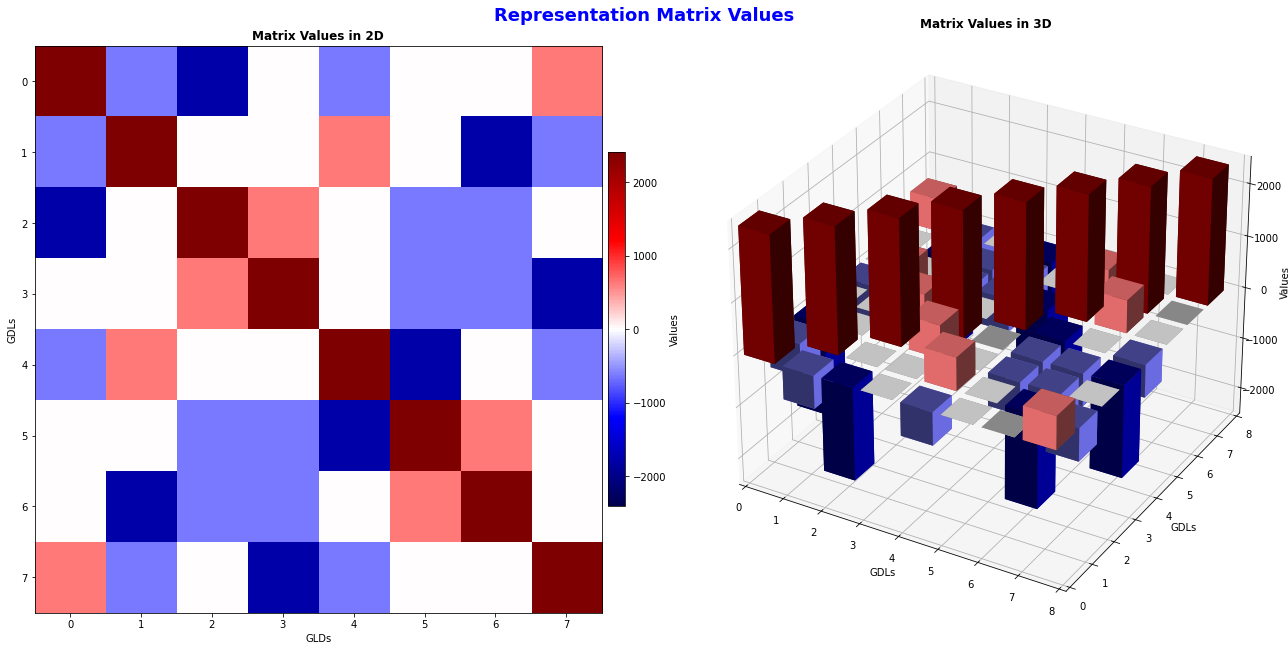

In [9]:
S3d = M_visual_2D_3D(S)
S3d.M_visual()

* SLL

In [10]:
SLL = S[0:gdl,0:gdl]
SLL_df = pd.DataFrame(SLL,index= rowsS[0:gdl], columns=[f'GDLg_{i+1}' for i in range(gdl)])                             # Convert stiffness matrix (SLL) to DataFrame
print("=" * 120)                                                                                                        # Print table separator
print('Global Structure Stiffness Matrix, SLL')                                                                         # Print table title
print("=" * 120)                                                                                                        # Print table separator
SLL_df.round(3)   

Global Structure Stiffness Matrix, SLL


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5
GDLg_1,2411.062,-629.779,-1781.283,0.000,-629.779
GDLg_2,-629.779,2411.062,0.000,0.000,629.779
GDLg_3,-1781.283,0.000,2411.062,629.779,-0.000
GDLg_4,0.000,0.000,629.779,2411.062,-0.000
GDLg_5,-629.779,629.779,-0.000,-0.000,2411.062


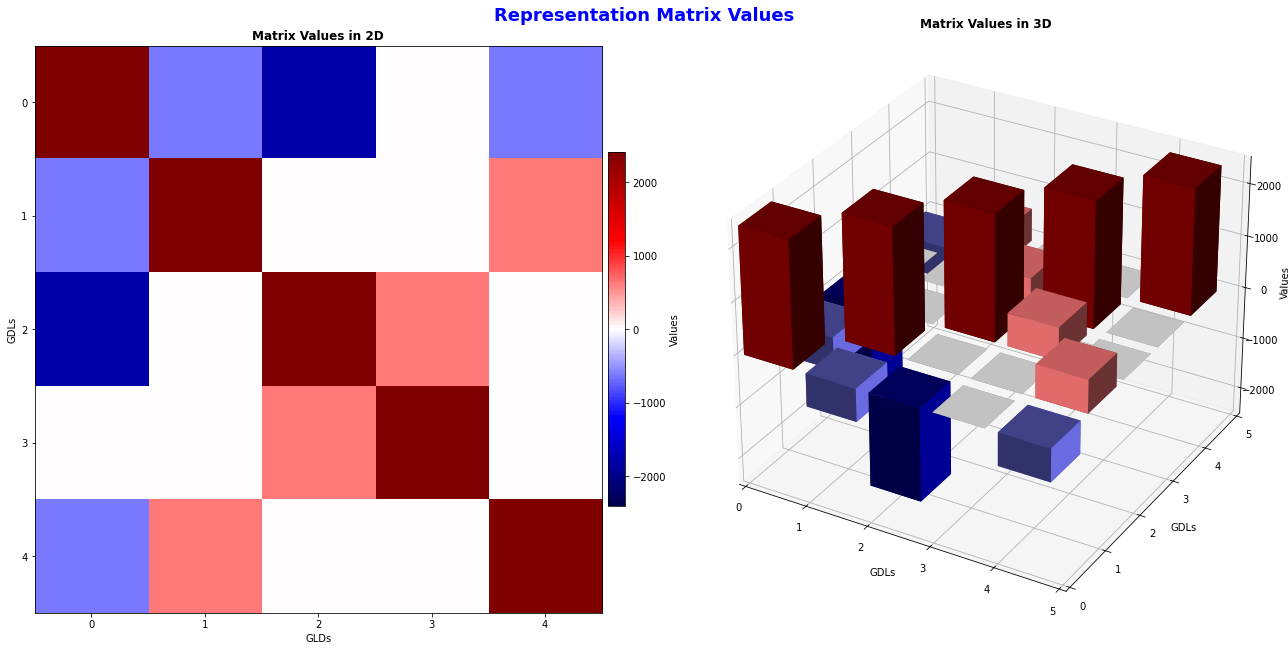

In [11]:
SLL3d = M_visual_2D_3D(SLL)
SLL3d.M_visual()

### Calculation of Global Displacement.

#### Load Nodal Vector

In [12]:
P = np.zeros(gdl)
P[0] = 5
P = np.vstack(P)

P_df = pd.DataFrame(P,index= rowsS[0:gdl], columns=['Loads'])                             # Convert stiffness matrix (SLL) to DataFrame
print("=" * 120)                                                                                                        # Print table separator
print('Load Nodal Vector [P]')                                                                         # Print table title
print("=" * 120)                                                                                                        # Print table separator
P_df.round(3) 

Load Nodal Vector [P]


,Loads
GDLg_1,5.0
GDLg_2,0.0
GDLg_3,0.0
GDLg_4,0.0
GDLg_5,0.0


In [13]:
SLL_inv = np.linalg.inv(SLL)
delta_g = SLL_inv@P
delta_g

array([[ 0.00677661],
       [ 0.00140348],
       [ 0.00537313],
       [-0.00140348],
       [ 0.00140348]])